# Distributions and Sampling in PyTorch

In [6]:
import matplotlib.pyplot as plt
import torch
import torch.distributions as dist

In [11]:
print(bernoulli_distribution)

Bernoulli(probs: tensor([0.5000]))


# Bernoulli principal
The Bernoulli distribution is one of the most fundamental concepts in probability theory and statistics. It models a single random experiment that can result in only two possible outcomes: success or failure.

## Distribution definitions

tensor(0.4600)
Mean of Bernoulli samples:  0.4600
----------------Normal Distribution:-------------------
Mean of Normal samples:  0.0294
Variance of Normal samples:  0.9807
----------------End of Normal Distribution------------------



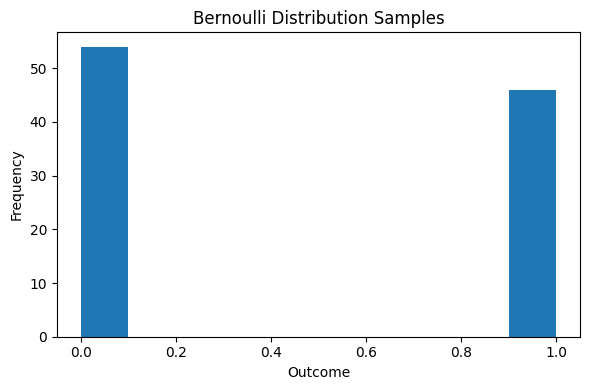

In [39]:
# Define a Bernoulli distribution for coin tossing
# Let's assume a fair coin, so p=0.5
bernoulli_distribution = dist.Bernoulli(torch.tensor([0.5]))

#this just samples
for _ in range(10):
    sample = bernoulli_distribution.sample()
    #print(sample.item())

# Plotting the samples
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Sampling from the Bernoulli distribution
bernoulli_samples = bernoulli_distribution.sample((100,))

#compute mean
mean = torch.mean(bernoulli_samples)
print(mean)
#extract only float value from tensor
mean = mean.item()
print(f"Mean of Bernoulli samples: {mean: .4f}")

#lets see normal distribution
print("----------------Normal Distribution:-------------------")
normal = dist.Normal(torch.tensor([0.0]), torch.tensor([1.0])) #mean on 0 and std on 1
mean = torch.mean(normal.sample((1000,))).item()
var = torch.var(normal.sample((1000,))).item()
print(f"Mean of Normal samples: {mean: .4f}")
print(f"Variance of Normal samples: {var: .4f}")
print("----------------End of Normal Distribution------------------\n")

# Bernoulli samples histogram
ax.hist(bernoulli_samples.numpy())
ax.set_title("Bernoulli Distribution Samples")
ax.set_xlabel("Outcome")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## Sampling is biased

In [41]:
# We can see that the samples are always biased.
# The more samples we take, the less visible the bias is.

for n in [10, 100, 1000, 10000]:
    bernoulli_samples = bernoulli_distribution.sample((n,))
    print(f"Frequency of heads in {n} samples:", torch.mean(bernoulli_samples).item())

# compute the nuumber of heads in the 1000 Bernoulli samples
bernoulli_samples = bernoulli_distribution.sample((1000,))

print("Number of heads:", torch.sum(bernoulli_samples).item())
print("Frequency of heads:", torch.mean(bernoulli_samples).item())

Frequency of heads in 10 samples: 0.5
Frequency of heads in 100 samples: 0.5699999928474426
Frequency of heads in 1000 samples: 0.5270000100135803
Frequency of heads in 10000 samples: 0.49959999322891235
Number of heads: 480.0
Frequency of heads: 0.47999998927116394


## Gaussian Sampling

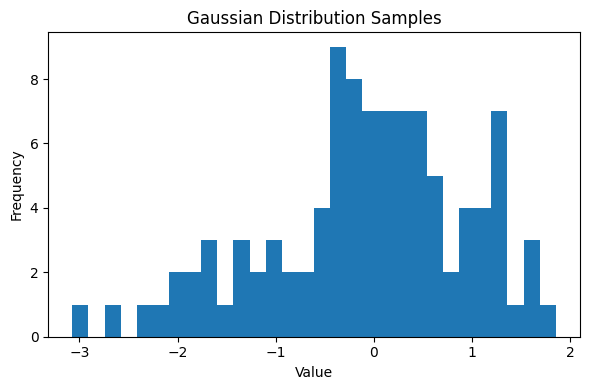

Mean of Gaussian samples: -0.07498924434185028
Mean of 10 Gaussian samples: 0.14287084341049194
Mean of 100 Gaussian samples: -0.05190277099609375
Mean of 1000 Gaussian samples: 0.006386783439666033
Mean of 10000 Gaussian samples: 0.0037031371612101793


In [32]:
# For simplicity, let's assume a standard normal distribution with mean=0 and std=1
gaussian_distribution = dist.Normal(torch.tensor([0.0]), torch.tensor([1.0]))

# Plotting the samples
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Sampling from the Gaussian distribution
gaussian_samples = gaussian_distribution.sample((100,))

# Gaussian samples histogram
ax.hist(gaussian_samples.numpy(), bins=30)
ax.set_title("Gaussian Distribution Samples")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# compute the mean of the 1000 Gaussian samples
print("Mean of Gaussian samples:", torch.mean(gaussian_samples).item())

for n in [10, 100, 1000, 10000]:
    gaussian_samples = gaussian_distribution.sample((n,))
    print(f"Mean of {n} Gaussian samples:", torch.mean(gaussian_samples).item())


## Probability Density Function (PDF)

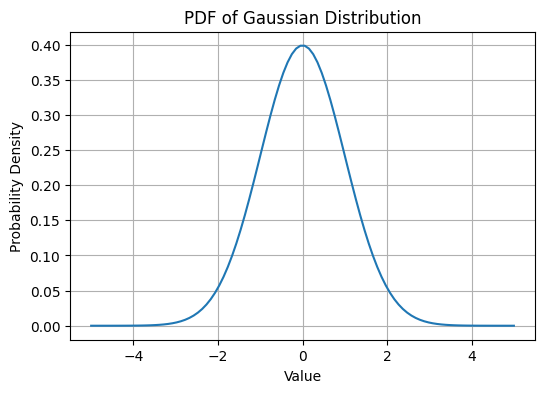

In [16]:
# Probability Density Function (PDF) values for Gaussian Distribution at different points
x_values = torch.linspace(-5, 5, 100)
pdf_values = torch.exp(gaussian_distribution.log_prob(x_values))

# Plotting PDF of Gaussian Distribution
plt.figure(figsize=(6, 4))
plt.plot(x_values.numpy(), pdf_values.numpy())
plt.title("PDF of Gaussian Distribution")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.grid(True)
plt.show()